# Tesla Charging History

Use the same file we started in the api notebook.

In [1]:
import os, sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

In [2]:
import settings.tesla_api as util
import settings.analysis as analysis

<img
src='https://media0.giphy.com/media/v1.Y2lkPTc5MGI3NjExbDk5ZXJqZnoxMjVsdHk0YjdzdnUydHNqbnF0MDlmY3libWtmM2FvOSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/gZkvEhS20Q3pONoPGS/giphy.gif'
    width='300px'
/>

#### Instantiate

Using the car's id from the API notebook, you can send requests with your car's VIN # to get unique details.

In [3]:
tsla = util.Tesla(id=3744545368547415)

With the VIN added by the class, you can get charge details from the vehicle specs dictionary:

In [4]:
charge_state = tsla.get_vehicle_specs()['charge_state']
print(f'Usable battery remaining in car: {charge_state['usable_battery_level']}%')
print(f'Milage remaining in car battery: {charge_state['battery_range']} miles')

Usable battery remaining in car: 66%
Milage remaining in car battery: 190.63 miles


## Analyze Charging History

The API allows you to get a charging history that shows some interesting details, including the exact fees involved with the session. 

In [5]:
charging = tsla.get_charge_history()

In [6]:
charging[['sessionId', 'siteLocationName', 'fees', 'chargeStartDateTime', 'chargeStopDateTime']].sort_values(by='chargeStartDateTime', ascending=False).head()

,sessionId,siteLocationName,fees,chargeStartDateTime,chargeStopDateTime
0,740081655,"Jackson, MI","[{'sessionFeeId': 1469186840, 'feeType': 'CHAR...",2026-08-14T11:53:15-04:00,2026-08-14T12:06:19-04:00
100,740081655,"Jackson, MI","[{'sessionFeeId': 1469186840, 'feeType': 'CHAR...",2026-08-14T11:53:15-04:00,2026-08-14T12:06:19-04:00
25,740081655,"Jackson, MI","[{'sessionFeeId': 1469186840, 'feeType': 'CHAR...",2026-08-14T11:53:15-04:00,2026-08-14T12:06:19-04:00
200,740081655,"Jackson, MI","[{'sessionFeeId': 1469186840, 'feeType': 'CHAR...",2026-08-14T11:53:15-04:00,2026-08-14T12:06:19-04:00
150,740081655,"Jackson, MI","[{'sessionFeeId': 1469186840, 'feeType': 'CHAR...",2026-08-14T11:53:15-04:00,2026-08-14T12:06:19-04:00


### Rolling History

Something interesting that we can start to build with this number is a rolling history of charging. Below plots my lifetime charging history. What is interesting is that I notice only times where I used a supercharger, and not my home charger, are returned in the API response.

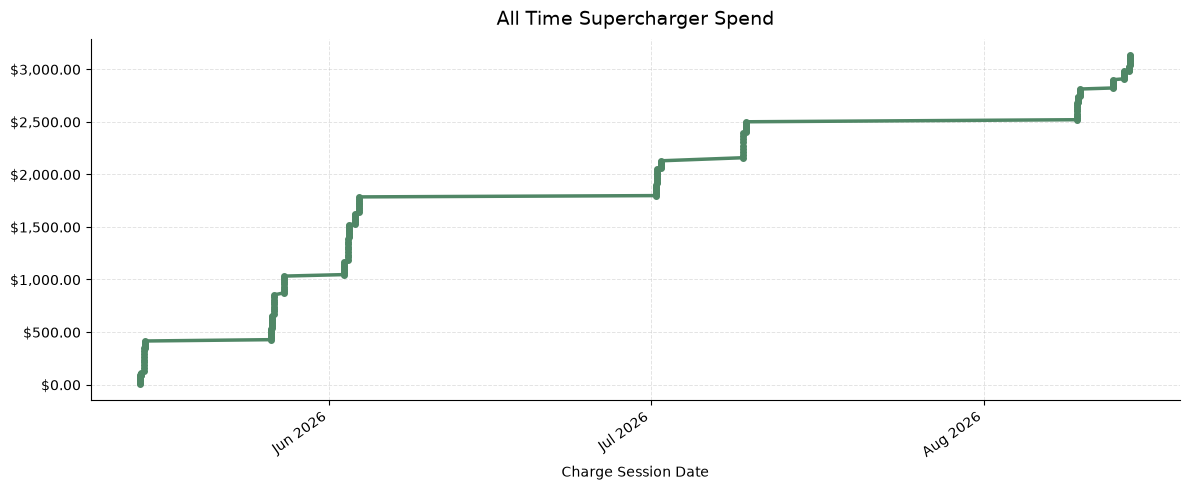

In [7]:
fig, ax, summary = analysis.plot_charging_history_rolling_sum(charging)

In [8]:
total_cost = summary['rolling_total'].iloc[-1].item()
total_miles = round(tsla.get_vehicle_specs()['vehicle_state']['odometer'],2)

In [9]:
print(f'Traveled: {total_miles} miles')
print(f'Supercharger Cost/Mile: ${round(total_cost/total_miles,3)}')

Traveled: 44493.83 miles
Supercharger Cost/Mile: $0.07


# Comparative Analysis

The chart below plots **cost against miles driven**. Both lines use a constant rate: Tesla is total supercharger spend divided by odometer miles, and gas is `gas_price_per_gallon / mpg`. Home charging is not in the Fleet charging-history response, so Tesla cost here is supercharger spend only and your overall cost should consider your energy bill.

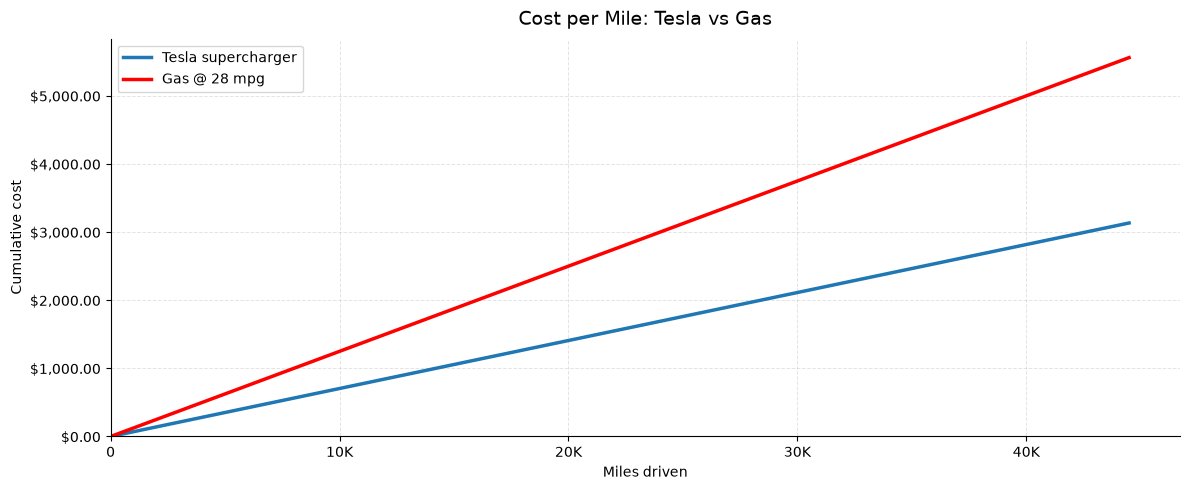

In [10]:
fig, ax, summary = analysis.plot_charging_vs_gas_cost(
    charging,
    mpg=28.0,
    gas_price_per_gallon=3.50,
    total_miles=total_miles,
)